In [2]:
from google.colab import files
uploaded = files.upload()

Saving continuous dataset.csv to continuous dataset.csv
Saving train_dataframes.xlsx to train_dataframes.xlsx
Saving weekly pre-dispatch forecast.csv to weekly pre-dispatch forecast (1).csv
Saving test_dataframes.xlsx to test_dataframes (1).xlsx


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import pickle

In [4]:
df = pd.read_csv("continuous dataset.csv", parse_dates=["datetime"])

print(df.head())
print(df.head())
print(df.columns)

             datetime  nat_demand    T2M_toc  ...  Holiday_ID  holiday  school
0 2015-01-03 01:00:00    970.3450  25.865259  ...           0        0       0
1 2015-01-03 02:00:00    912.1755  25.899255  ...           0        0       0
2 2015-01-03 03:00:00    900.2688  25.937280  ...           0        0       0
3 2015-01-03 04:00:00    889.9538  25.957544  ...           0        0       0
4 2015-01-03 05:00:00    893.6865  25.973840  ...           0        0       0

[5 rows x 17 columns]
             datetime  nat_demand    T2M_toc  ...  Holiday_ID  holiday  school
0 2015-01-03 01:00:00    970.3450  25.865259  ...           0        0       0
1 2015-01-03 02:00:00    912.1755  25.899255  ...           0        0       0
2 2015-01-03 03:00:00    900.2688  25.937280  ...           0        0       0
3 2015-01-03 04:00:00    889.9538  25.957544  ...           0        0       0
4 2015-01-03 05:00:00    893.6865  25.973840  ...           0        0       0

[5 rows x 17 columns]
Index(

In [5]:
df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.day_of_week
df["month"] =   df["datetime"].dt.month

In [6]:
df["demand_class"] = pd.qcut(df["nat_demand"], q=3, labels=[0,1,2])

In [7]:
features = [
    "T2M_toc", "QV2M_toc", "TQL_toc", "W2M_toc",
    "T2M_san", "QV2M_san", "TQL_san", "W2M_san",
    "T2M_dav", "QV2M_dav", "TQL_dav", "W2M_dav",
    "Holiday_ID", "holiday", "school",
    "hour", "dayofweek", "month"
]

X = df[features].values
y = df["demand_class"].astype(int).values

In [8]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
n_classes = 3
prototypes_per_class = 9

prototypes = []
proto_labels = []

for c in range(n_classes):

    class_samples = X_scaled[y == c]

    chosen = class_samples[np.random.choice(len(class_samples), prototypes_per_class, replace=False)]

    prototypes.append(chosen)

    proto_labels.extend([c] * prototypes_per_class)

prototypes = np.vstack(prototypes)
proto_labels = np.array(proto_labels)

print("Prototype shape:", prototypes.shape)

Prototype shape: (27, 18)


In [35]:
def train_lvq(X, y, prototypes, proto_labels, lr=0.1, epochs=100):

    for epoch in range(epochs):

        indices = np.random.permutation(len(X))

        for i in indices:

            x = X[i]
            label = y[i]

            distances = np.linalg.norm(prototypes - x, axis=1)

            winner = np.argmin(distances)

            if proto_labels[winner] == label:
                prototypes[winner] += lr * (x - prototypes[winner])
            else:
                prototypes[winner] -= lr * (x - prototypes[winner])

        lr *= 0.9

    return prototypes

In [36]:
print(type(prototypes))
print(prototypes)

<class 'numpy.ndarray'>
[[ 1.41006142e-001  4.90171179e-001  6.97673971e-002  5.29142160e-001
   1.50618576e-001  4.98866046e-001  6.49496467e-002  4.34260324e-001
   8.37346699e-002  5.01342138e-001  1.86437777e-001  5.54067411e-001
   1.83438572e-001  1.00000000e+000  5.35097426e-024 -8.37945080e-003
   3.73293272e-001  8.03660718e-002]
 [ 2.25636569e-001  6.28224794e-001  2.21133931e-001  1.99449035e-001
   2.27072993e-001  6.85084992e-001  3.87264439e-001  2.26762233e-001
   1.85647325e-001  6.87700855e-001  4.54781528e-001  4.01631606e-001
   4.94065646e-323  4.94065646e-323  1.00000000e+000  8.17771274e-002
   3.14294013e-001  7.97364737e-001]
 [ 2.74565889e-001  6.54095402e-001  1.64948450e-001  2.27827048e-001
   2.63963195e-001  6.82049462e-001  2.05607961e-001  1.71154914e-001
   2.12717735e-001  6.67475214e-001  2.99138444e-001  2.82398514e-001
  -3.95252517e-323 -3.95252517e-323  1.00000000e+000  1.67825508e-001
   8.72568139e-001  6.47378348e-001]
 [ 1.08090927e-001  5.910

In [37]:
prototypes = train_lvq(X_scaled, y, prototypes, proto_labels)

In [38]:
def predict_lvq(X, prototypes, proto_labels):

    preds = []

    for x in X:

        distances = np.linalg.norm(prototypes - x, axis=1)

        winner = np.argmin(distances)

        preds.append(proto_labels[winner])

    return np.array(preds)

In [39]:
y_pred = predict_lvq(X_scaled, prototypes, proto_labels)
print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 0.740405427905428


In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred)
print(cm)

[[13811  1782   423]
 [ 3503  9311  3202]
 [  444  3119 12453]]


In [41]:
import pickle

model = {
    "prototypes": prototypes,
    "proto_labels": proto_labels,
    "scaler": scaler
}

with open("lvq_energy_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [47]:
from google.colab import files
files.download("lvq_energy_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
df["predicted_class"] = y_pred

In [43]:
df[["nat_demand","demand_class","predicted_class"]].head()

,nat_demand,demand_class,predicted_class
0,970.3450,0,0
1,912.1755,0,0
2,900.2688,0,0
3,889.9538,0,0
4,893.6865,0,0


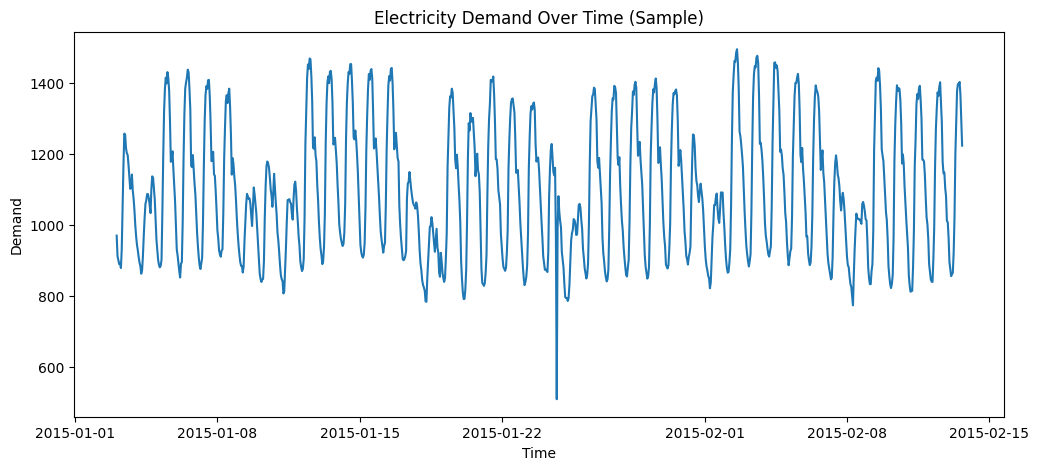

In [46]:
plt.figure(figsize=(12,5))

plt.plot(df["datetime"][:1000], df["nat_demand"][:1000])

plt.title("Electricity Demand Over Time (Sample)")
plt.xlabel("Time")
plt.ylabel("Demand")

plt.show()